# Marriott Procurement Spend Analysis
### 2019 Purchase Register Analysis — 4 Hotels (123 Company, ABC Company, LMN Company, XYZ Company)

**Prepared by:** Keshav.                                               
**Date:** July 2026

---

## Project Introduction

This notebook performs an end-to-end procurement spend analysis on 2019 purchase register data collected from four Marriott hotels. The objective is to consolidate the disparate purchase registers into a single clean dataset.

1. **Pepsi Products Spend Analysis** — by product, supplier, hotel, and other insights
2. **Kimberly-Clark Products Spend Analysis** — by product, supplier, hotel, and other insights
3. **Major Observations** on Pepsi & Kimberly-Clark spend
4. **Additional Analysis** of choice (category-wise, supplier-wise, buyer-wise spend)


---
## Module 1: Project Setup & Data Loading

In [54]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Read Excel Files

The four hotel purchase registers arrive in different raw layouts:
- **123 Company** and **ABC Company** and **LMN Company**: header is in the first row.
- **XYZ Company**: the sheet has 2 blank rows before the real header row, so it needs `header=2`.

We also read the two reference/master product lists: **Pepsi_Product_List.xlsx** and **KC_Product_List.xlsx**.

In [6]:
DATA_DIR = "data"

df_123 = pd.read_excel(f"{DATA_DIR}/123_Company.xlsx")
df_abc = pd.read_excel(f"{DATA_DIR}/ABC_Company.xlsx")
df_lmn = pd.read_excel(f"{DATA_DIR}/LMN_Company.xlsx")
df_xyz = pd.read_excel(f"{DATA_DIR}/XYZ_Company.xlsx", header=2)   # first 2 rows are blank in the raw file

pepsi_list = pd.read_excel(f"{DATA_DIR}/Pepsi_Product_List.xlsx")
kc_list = pd.read_excel(f"{DATA_DIR}/KC_Product_List.xlsx")

print("123 Company :", df_123.shape)
print("ABC Company :", df_abc.shape)
print("LMN Company :", df_lmn.shape)
print("XYZ Company :", df_xyz.shape)
print("Pepsi list  :", pepsi_list.shape)
print("KC list     :", kc_list.shape)

123 Company : (70996, 8)
ABC Company : (35117, 10)
LMN Company : (53396, 11)
XYZ Company : (89326, 9)
Pepsi list  : (22, 3)
KC list     : (69, 5)


### Explore Each Dataset

In [58]:
print("="*80)
print("123 COMPANY — sample rows")
print("="*80)
display(df_123.head(3))

print("="*80)
print("ABC COMPANY — sample rows")
print("="*80)
display(df_abc.head(3))

print("="*80)
print("LMN COMPANY — sample rows")
print("="*80)
display(df_lmn.head(3))

print("="*80)
print("XYZ COMPANY — sample rows")
print("="*80)
display(df_xyz.head(3))

123 COMPANY — sample rows


,Supplier name,Received date,Category name,Product name,UOM,Rec'd qty,Unit price,Extension
0,Sw Foods & Beverages Pvt. Ltd.,2019-01-02,Fish Frozen,Fish Frozen Prawns Head/less Pld T/on 26/30,KG,50.00,620.00,"31,000.00"
1,Preferred Food Circles Pvt Ltd,2019-01-02,Fish Fresh,Fish Fresh Cat fish Fillet (Kg),KG,50.00,250.00,"12,500.00"
2,Preferred Food Circles Pvt Ltd,2019-01-02,Fish Fresh,Fish Fresh Sole River Fillet (Kg),KG,15.00,795.00,"11,925.00"


ABC COMPANY — sample rows


,Store,Bill No,Bill Date,Vendor Name,Item ID,Product Description,UOM,Qty,Unit Cost,Total Cost
0,PERISHABLE,24449,2018-12-28,SRI SAI RAM FOODDS,857.00,FRENCH FRIES 9MM,KG,20.00,108.43,"2,168.60"
1,PERISHABLE,10282,2018-12-28,SRI ANNAPURNA FRUITS AND VEGETABLES SUPP,418.00,BRINJA SMALL,KG,3.00,12.00,36.00
2,PERISHABLE,10282,2018-12-28,SRI ANNAPURNA FRUITS AND VEGETABLES SUPP,426.00,CARROT,KG,30.00,23.00,690.00


LMN COMPANY — sample rows


,Purchase Date,Category,Sub Category,Product,Product Description,Quantity,Purchase Unit,Purchase Info,Total Cost,Vendor Name,Unit Cost
0,2019-01-01,Groceries,Packed n Tin Foods,1050516,Bread Sandwich Long Loaf *800Gms,25.00,800gms,800gms,900.00,Galaxy Entertainment Corporation Ltd,36.00
1,2019-01-01,Vegetables and Fruits,Vegetables Indian,1080051,Mushroom Button Fresh,2.00,Kilogram,Kilogram,290.00,SLNS MARKETING,145.00
2,2019-01-01,Vegetables and Fruits,Vegetables Indian,1080051,Mushroom Button Fresh,2.00,Kilogram,Kilogram,290.00,SLNS MARKETING,145.00


XYZ COMPANY — sample rows


,Supplier name,Received date,Product name,UOM,Rec'd qty,Unit price,Rec'd ext amt,Local Currency,Category name
0,Phalke & Co,2019-01-03,Fruit Water Melon Irani,KG,300.00,14.00,"4,200.00",INR,Fruit Fresh
1,Phalke & Co,2019-01-03,Fruit Pommegranate Kabuli,KG,10.00,110.00,"1,100.00",INR,Fruit Fresh
2,Phalke & Co,2019-01-03,Fruit Pineapple W/O Leaf,KG,200.00,28.00,"5,600.00",INR,Fruit Fresh


In [60]:
print("="*80)
print("PEPSI PRODUCT LIST")
print("="*80)
display(pepsi_list.head(10))

print("="*80)
print("KIMBERLY LIST")
print("="*80)
display(kc_list.head(10))

PEPSI PRODUCT LIST


,Products,Business,Bottles/Cs
0,NaN,NaN,NaN
1,NaN,CSD,NaN
2,NaN,GRB,NaN
3,Pepsi/Dukes Lemonade/Mirinda Orange/Mirinda Le...,200 ml,24.00
4,NaN,250 ml,24.00
5,Pepsi/Dukes Lemonade/Mirinda Orange/Mirinda Le...,300 ml,24.00
6,Soda - Dukes/Lehar Everess,300 ml Soda,24.00
7,NaN,CANS,NaN
8,NaN,250 ml,24.00
9,250 ml Can,Dukes Tonic Water,24.00


KIMBERLY LIST


,Sr no,SKU Code,Material Description,Category,Specification
0,1,1272,KLEENEX BATHROOM ROLL 2PLY UNEMB,Bathroom Tissue,100 rolls × 200 Sheets
1,2,1308,KLEENEX BATHROOM TISSUE 250 UNEMB,Bathroom Tissue,100 rolls × 250 Sheets
2,3,1212,KIMSOFT BATHROOM TISSUE 375S,Bathroom Tissue,80 rolls × 375 Sheets
3,4,1169,KIMSOFT BATHROOM TISSUE 200S,Bathroom Tissue,150 rolls × 200 Sheets
4,5,4008,KLEENEX BATHROOM ROLL 2PLY IMPORTED,Bathroom Tissue,120 rolls × 160 Sheets
5,6,1268,SCOTT HYGIENIC B/TISS 125S,Bathroom Tissue,100 × 125 Pulls
6,7,1317,Kleenex Bathroom Tissue,Bathroom Tissue,200 rolls × 135 Sheets
7,8,1368,Kleenex Bathroom Tissue,Bathroom Tissue,80 rolls × 375 Sheets
8,9,4002,KIMSOFT BATHROOM TISSUE 460S,Bathroom Tissue,80 rolls × 460 Sheets
9,10,4003,Kimsoft Toilet Roll,Bathroom Tissue,100 rolls × 230 Sheets


### Check Shape, Info, Missing Values, Duplicates

We check structure and data quality of each of the 4 purchase registers before doing any cleaning.

In [9]:
registers = {
    "123 Company": df_123,
    "ABC Company": df_abc,
    "LMN Company": df_lmn,
    "XYZ Company": df_xyz,
}

for name, df in registers.items():
    print(f"\n{'='*70}\n{name}\n{'='*70}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"\nColumn dtypes:\n{df.dtypes}")
    print(f"\nMissing values:\n{df.isnull().sum()}")
    print(f"\nFully duplicate rows: {df.duplicated().sum():,}")


123 Company
Shape: 70,996 rows x 8 columns

Column dtypes:
Supplier name            object
Received date    datetime64[ns]
Category name            object
Product name             object
UOM                      object
Rec'd qty               float64
Unit price              float64
Extension               float64
dtype: object

Missing values:
Supplier name    1
Received date    1
Category name    1
Product name     1
UOM              1
Rec'd qty        1
Unit price       1
Extension        0
dtype: int64

Fully duplicate rows: 7,336

ABC Company
Shape: 35,117 rows x 10 columns

Column dtypes:
Store                          object
Bill No                        object
Bill Date              datetime64[ns]
Vendor Name                    object
Item ID                       float64
Product Description            object
UOM                            object
Qty                           float64
Unit Cost                     float64
Total Cost                    float64
dtype: object

Mis


Fully duplicate rows: 7,336

ABC Company
Shape: 35,117 rows x 10 columns

Column dtypes:
Store                             str
Bill No                           str
Bill Date              datetime64[us]
Vendor Name                       str
Item ID                       float64
Product Description               str
UOM                               str
Qty                           float64
Unit Cost                     float64
Total Cost                    float64
dtype: object

Missing values:
Store                  1
Bill No                1
Bill Date              1
Vendor Name            1
Item ID                1
Product Description    0
UOM                    1
Qty                    1
Unit Cost              1
Total Cost             0
dtype: int64

Fully duplicate rows: 362

LMN Company
Shape: 53,396 rows x 11 columns

Column dtypes:
Purchase Date          datetime64[us]
Category                          str
Sub Category                      str
Product                         in


Fully duplicate rows: 21,933


**Observation:** XYZ Company's sheet contains ~19,000 fully blank rows (likely spacer rows in the original export) which will be dropped during cleaning. All four registers have a small number of duplicate rows that need de-duplication. Column names differ across all four files, which we standardize next.

### Standardize Column Names

Each hotel uses different column names for the same real-world fields (supplier, date, product, category, quantity, unit price, total spend). We map each register to one common schema:

| Unified column | 123 Company | ABC Company | LMN Company | XYZ Company |
|---|---|---|---|---|
| Hotel | *(added)* | *(added)* | *(added)* | *(added)* |
| Date | Received date | Bill Date | Purchase Date | Received date |
| Category | Category name | Store | Category | Category name |
| Supplier | Supplier name | Vendor Name | Vendor Name | Supplier name |
| Product | Product name | Product Description | Product Description | Product name |
| UOM | UOM | UOM | Purchase Unit | UOM |
| Quantity | Rec'd qty | Qty | Quantity | Rec'd qty |
| UnitPrice | Unit price | Unit Cost | Unit Cost | Unit price |
| TotalSpend | Extension | Total Cost | Total Cost | Rec'd ext amt |

ABC Company has no explicit "category" column, so its **Store** field (PERISHABLE, BEVERAGE, BUTCHERY, FOOD, ENGINEERING, DIRECT, TOBACCO) is used as the category equivalent. LMN Company's own "Product" column is actually an internal SKU code, so it is renamed to `ProductCode` and kept as reference, while "Product Description" becomes the unified `Product` field.

In [10]:
column_maps = {
    "123": {
        'Supplier name': 'Supplier', 'Received date': 'Date', 'Category name': 'Category',
        'Product name': 'Product', 'UOM': 'UOM', "Rec'd qty": 'Quantity',
        'Unit price': 'UnitPrice', 'Extension': 'TotalSpend'
    },
    "ABC": {
        'Store': 'Category', 'Bill Date': 'Date', 'Vendor Name': 'Supplier',
        'Product Description': 'Product', 'UOM': 'UOM', 'Qty': 'Quantity',
        'Unit Cost': 'UnitPrice', 'Total Cost': 'TotalSpend'
    },
    "LMN": {
        'Purchase Date': 'Date', 'Category': 'Category', 'Vendor Name': 'Supplier',
        'Product': 'ProductCode', 'Product Description': 'Product',
        'Purchase Unit': 'UOM', 'Quantity': 'Quantity',
        'Unit Cost': 'UnitPrice', 'Total Cost': 'TotalSpend'
    },
    "XYZ": {
        'Supplier name': 'Supplier', 'Received date': 'Date', 'Category name': 'Category',
        'Product name': 'Product', 'UOM': 'UOM', "Rec'd qty": 'Quantity',
        'Unit price': 'UnitPrice', "Rec'd ext amt": 'TotalSpend'
    },
}

c123 = df_123.rename(columns=column_maps["123"]); c123['Hotel'] = '123 Company'
cabc = df_abc.rename(columns=column_maps["ABC"]); cabc['Hotel'] = 'ABC Company'
clmn = df_lmn.rename(columns=column_maps["LMN"]); clmn['Hotel'] = 'LMN Company'
cxyz = df_xyz.rename(columns=column_maps["XYZ"]); cxyz['Hotel'] = 'XYZ Company'

print("Columns standardized for all 4 hotels.")
print("123 ->", [c for c in c123.columns if c in ['Hotel','Date','Category','Supplier','Product','UOM','Quantity','UnitPrice','TotalSpend']])

Columns standardized for all 4 hotels.
123 -> ['Supplier', 'Date', 'Category', 'Product', 'UOM', 'Quantity', 'UnitPrice', 'TotalSpend', 'Hotel']


---
## Module 2: Data Cleaning & Consolidation

### Rename Columns & Add Hotel Column
(Already done in Module 1 — each hotel dataframe now has a common set of columns plus a `Hotel` identifier column.)

### Merge All Four Purchase Registers

In [11]:
UNIFIED_COLS = ['Hotel', 'Date', 'Category', 'Supplier', 'Product', 'UOM', 'Quantity', 'UnitPrice', 'TotalSpend']

master = pd.concat(
    [c123[UNIFIED_COLS], cabc[UNIFIED_COLS], clmn[UNIFIED_COLS], cxyz[UNIFIED_COLS]],
    ignore_index=True
)

print(f"Combined register (raw): {master.shape[0]:,} rows x {master.shape[1]} columns")
master.head()

Combined register (raw): 248,835 rows x 9 columns


,Hotel,Date,Category,Supplier,Product,UOM,Quantity,UnitPrice,TotalSpend
0,123 Company,2019-01-02,Fish Frozen,Sw Foods & Beverages Pvt. Ltd.,Fish Frozen Prawns Head/less Pld T/on 26/30,KG,50.00,620.00,"31,000.00"
1,123 Company,2019-01-02,Fish Fresh,Preferred Food Circles Pvt Ltd,Fish Fresh Cat fish Fillet (Kg),KG,50.00,250.00,"12,500.00"
2,123 Company,2019-01-02,Fish Fresh,Preferred Food Circles Pvt Ltd,Fish Fresh Sole River Fillet (Kg),KG,15.00,795.00,"11,925.00"
3,123 Company,2019-01-02,Chicken,Rose Foods,Chicken Whole With Skin 900 to 1300gm,KG,50.00,130.00,"6,500.00"
4,123 Company,2019-01-02,Chicken,Rose Foods,Chicken Broiler without skin whole,KG,141.00,145.00,"20,445.00"


### Remove Duplicates

In [12]:
# Drop rows that are fully blank across the key fields (these are spacer rows, mostly from XYZ Company)
before = len(master)
master = master.dropna(subset=['Product', 'Supplier', 'Date'], how='all')
print(f"Dropped {before - len(master):,} fully-blank rows -> {len(master):,} rows remain")

# Remove exact duplicate transaction rows
before = len(master)
master = master.drop_duplicates()
print(f"Dropped {before - len(master):,} exact duplicate rows -> {len(master):,} rows remain")

Dropped 19,341 fully-blank rows -> 229,494 rows remain
Dropped 19,860 exact duplicate rows -> 209,634 rows remain


Dropped 19,860 exact duplicate rows -> 209,634 rows remain


### Handle Missing Values

In [13]:
# Convert data types
master['Date'] = pd.to_datetime(master['Date'], errors='coerce')
for col in ['Quantity', 'UnitPrice', 'TotalSpend']:
    master[col] = pd.to_numeric(master[col], errors='coerce')

print("Missing values after type conversion:")
print(master.isnull().sum())

# Drop rows with no usable date, product, or spend value — these can't be analyzed
before = len(master)
master = master.dropna(subset=['Date', 'Product', 'TotalSpend'])
print(f"\nDropped {before - len(master):,} rows with missing Date/Product/TotalSpend -> {len(master):,} rows remain")

# Remove non-positive/erroneous spend rows (returns, credits, zero-value data entry errors)
before = len(master)
master = master[master['TotalSpend'] > 0]
print(f"Dropped {before - len(master):,} rows with zero/negative spend -> {len(master):,} rows remain")

Missing values after type conversion:
Hotel         0
Date          1
Category      1
Supplier      1
Product       0
UOM           1
Quantity      1
UnitPrice     1
TotalSpend    0
dtype: int64

Dropped 1 rows with missing Date/Product/TotalSpend -> 209,633 rows remain
Dropped 161 rows with zero/negative spend -> 209,472 rows remain


### Standardize Product & Supplier Names

In [14]:
# Trim whitespace and uppercase text fields so the same product/supplier isn't split
# across multiple casings/spacings (e.g. "Pepsi " vs "PEPSI" vs " Pepsi")
for col in ['Category', 'Supplier', 'Product', 'UOM']:
    master[col] = master[col].astype(str).str.strip().str.upper()
    master[col] = master[col].replace('NAN', np.nan)

master['Category'] = master['Category'].fillna('UNCATEGORIZED')
master['UOM'] = master['UOM'].fillna('NOT SPECIFIED')

print("Sample standardized values:")
print(master[['Hotel','Category','Supplier','Product']].head())

Sample standardized values:
         Hotel     Category                        Supplier                                      Product
0  123 Company  FISH FROZEN  SW FOODS & BEVERAGES PVT. LTD.  FISH FROZEN PRAWNS HEAD/LESS PLD T/ON 26/30
1  123 Company   FISH FRESH  PREFERRED FOOD CIRCLES PVT LTD             FISH FRESH CAT FISH FILLET  (KG)
2  123 Company   FISH FRESH  PREFERRED FOOD CIRCLES PVT LTD           FISH FRESH SOLE RIVER FILLET  (KG)
3  123 Company      CHICKEN                      ROSE FOODS        CHICKEN WHOLE WITH SKIN 900 TO 1300GM
4  123 Company      CHICKEN                      ROSE FOODS           CHICKEN BROILER WITHOUT SKIN WHOLE


### Create Month, Quarter, Year

In [15]:
master['Year'] = master['Date'].dt.year
master['Month'] = master['Date'].dt.month
master['MonthName'] = master['Date'].dt.strftime('%b')
master['Quarter'] = 'Q' + master['Date'].dt.quarter.astype(str)

# The brief covers 2019 data; a handful of rows fall right at year-end/year-start boundary dates.
# We keep the full range but flag the primary analysis year.
print(master['Year'].value_counts().sort_index())

Year
2018       238
2019    209234
Name: count, dtype: int64


### Export Cleaned Dataset

In [16]:
master.to_csv("cleaned_master_purchase_register.csv", index=False)
master.to_excel("cleaned_master_purchase_register.xlsx", index=False)

print(f"Final cleaned & consolidated dataset: {master.shape[0]:,} rows x {master.shape[1]} columns")
print("Saved as cleaned_master_purchase_register.csv / .xlsx")
master.head()

Final cleaned & consolidated dataset: 209,472 rows x 13 columns
Saved as cleaned_master_purchase_register.csv / .xlsx


,Hotel,Date,Category,Supplier,Product,UOM,Quantity,UnitPrice,TotalSpend,Year,Month,MonthName,Quarter
0,123 Company,2019-01-02,FISH FROZEN,SW FOODS & BEVERAGES PVT. LTD.,FISH FROZEN PRAWNS HEAD/LESS PLD T/ON 26/30,KG,50.00,620.00,"31,000.00",2019,1,Jan,Q1
1,123 Company,2019-01-02,FISH FRESH,PREFERRED FOOD CIRCLES PVT LTD,FISH FRESH CAT FISH FILLET (KG),KG,50.00,250.00,"12,500.00",2019,1,Jan,Q1
2,123 Company,2019-01-02,FISH FRESH,PREFERRED FOOD CIRCLES PVT LTD,FISH FRESH SOLE RIVER FILLET (KG),KG,15.00,795.00,"11,925.00",2019,1,Jan,Q1
3,123 Company,2019-01-02,CHICKEN,ROSE FOODS,CHICKEN WHOLE WITH SKIN 900 TO 1300GM,KG,50.00,130.00,"6,500.00",2019,1,Jan,Q1
4,123 Company,2019-01-02,CHICKEN,ROSE FOODS,CHICKEN BROILER WITHOUT SKIN WHOLE,KG,141.00,145.00,"20,445.00",2019,1,Jan,Q1


---
## Module 3: Exploratory Data Analysis (EDA)

### Dataset Summary

In [17]:
print("PROCUREMENT DATASET — OVERALL SUMMARY")
print("="*50)
print(f"Date range        : {master['Date'].min().date()}  to  {master['Date'].max().date()}")
print(f"Total transactions: {len(master):,}")
print(f"Total spend       : Rs {master['TotalSpend'].sum():,.0f}")
print(f"Number of hotels  : {master['Hotel'].nunique()}")
print(f"Number of suppliers: {master['Supplier'].nunique():,}")
print(f"Number of products : {master['Product'].nunique():,}")
print(f"Number of categories: {master['Category'].nunique():,}")

PROCUREMENT DATASET — OVERALL SUMMARY
Date range        : 2018-12-28  to  2019-12-31
Total transactions: 209,472
Total spend       : Rs 976,489,510
Number of hotels  : 4
Number of suppliers: 1,553
Number of products : 16,343
Number of categories: 249


### Total Spend, Number of Hotels, Suppliers, Products

In [18]:
summary_stats = pd.DataFrame({
    'Metric': ['Total Spend (Rs)', 'Hotels', 'Suppliers', 'Products', 'Categories', 'Transactions'],
    'Value': [
        f"{master['TotalSpend'].sum():,.0f}",
        master['Hotel'].nunique(),
        master['Supplier'].nunique(),
        master['Product'].nunique(),
        master['Category'].nunique(),
        f"{len(master):,}"
    ]
})
summary_stats

,Metric,Value
0,Total Spend (Rs),"976,489,510"
1,Hotels,4
2,Suppliers,1553
3,Products,16343
4,Categories,249
5,Transactions,"209,472"


### Category Analysis

In [19]:
category_spend = master.groupby('Category')['TotalSpend'].agg(['sum','count']).sort_values('sum', ascending=False)
category_spend.columns = ['TotalSpend', 'Transactions']
category_spend['SpendShare%'] = (category_spend['TotalSpend'] / category_spend['TotalSpend'].sum() * 100).round(2)
category_spend.head(15)

,TotalSpend,Transactions,SpendShare%
Category,,,
BUTCHERY,"48,296,380.00",4494,4.95
GROCERIES,"36,697,691.89",7725,3.76
GUEST SUPPLIES H/K,"30,128,661.96",1341,3.09
DRY GOODS OTHERS,"29,779,781.42",7188,3.05
FRUIT FRESH,"27,191,199.75",15586,2.78
HLP,"24,022,381.44",302,2.46
VEGETABLE FRESH,"23,922,907.13",40734,2.45
SPIRITS,"21,852,608.61",230,2.24
DAIRY OTHERS,"21,787,629.83",7555,2.23


### Hotel-wise Spend

In [20]:
hotel_spend = master.groupby('Hotel')['TotalSpend'].agg(['sum','count']).sort_values('sum', ascending=False)
hotel_spend.columns = ['TotalSpend', 'Transactions']
hotel_spend['SpendShare%'] = (hotel_spend['TotalSpend'] / hotel_spend['TotalSpend'].sum() * 100).round(2)
hotel_spend

,TotalSpend,Transactions,SpendShare%
Hotel,,,
XYZ Company,"401,389,558.16",67391,41.11
123 Company,"252,585,352.58",63513,25.87
LMN Company,"249,256,254.63",43942,25.53
ABC Company,"73,258,344.26",34626,7.50


### Supplier-wise Spend

In [21]:
supplier_spend = master.groupby('Supplier')['TotalSpend'].agg(['sum','count']).sort_values('sum', ascending=False)
supplier_spend.columns = ['TotalSpend', 'Transactions']
supplier_spend['SpendShare%'] = (supplier_spend['TotalSpend'] / supplier_spend['TotalSpend'].sum() * 100).round(2)
supplier_spend.head(15)

,TotalSpend,Transactions,SpendShare%
Supplier,,,
TELANGANA STATE BEVERAGE CORPORATION LIMITED,"48,641,229.43",547,4.98
LAKEFOREST WINES PVT.LTD.,"39,139,910.52",420,4.01
VIRCHAND KHIMJI,"25,453,233.24",4135,2.61
SUPER ENTERPRISES,"20,878,580.48",1204,2.14
INDIAN OIL CORPORATION LIMITED,"16,087,552.40",26,1.65
MRK FOODS PVT LTD,"15,771,748.52",2964,1.62
PHALKE & CO,"15,312,117.70",6966,1.57
CANDY SPIRITS PVT. LTD.,"15,080,618.93",169,1.54
KIMIRICA HUNTER INTERNATIONAL LLP,"14,607,352.92",613,1.50


### Product-wise Spend

In [22]:
product_spend = master.groupby('Product')['TotalSpend'].agg(['sum','count']).sort_values('sum', ascending=False)
product_spend.columns = ['TotalSpend', 'Transactions']
product_spend['SpendShare%'] = (product_spend['TotalSpend'] / product_spend['TotalSpend'].sum() * 100).round(2)
product_spend.head(15)

,TotalSpend,Transactions,SpendShare%
Product,,,
HSD (DIESEL),"15,695,580.00",19,1.61
LAMB LEG BABY,"11,032,988.90",165,1.13
CHICKEN THIGH BONELESS,"7,842,104.20",410,0.80
MUTTON CARCASS - LOCAL,"6,037,414.70",131,0.62
FISH RIVER SALMON WHITE,"5,352,462.50",190,0.55
CHICKEN TIKKA,"5,151,314.50",370,0.53
DIESEL,"5,081,040.00",72,0.52
WHISKY JW BLACK 750 ML,"4,498,770.00",6,0.46
SUNFLOWER OIL 15 LTR TIN/BRAND FORTUNE,"4,463,900.00",46,0.46


### Monthly Spend Trend

In [23]:
monthly_trend = master.groupby(['Year','Month','MonthName'])['TotalSpend'].sum().reset_index()
monthly_trend = monthly_trend.sort_values(['Year','Month'])
monthly_trend

,Year,Month,MonthName,TotalSpend
0,2018,12,Dec,"604,382.89"
1,2019,1,Jan,"79,050,084.45"
2,2019,2,Feb,"84,133,027.50"
3,2019,3,Mar,"88,010,127.92"
4,2019,4,Apr,"71,561,256.42"
5,2019,5,May,"70,415,577.87"
6,2019,6,Jun,"77,102,468.14"
7,2019,7,Jul,"79,473,384.00"
8,2019,8,Aug,"75,627,227.35"
9,2019,9,Sep,"75,485,097.77"


### Charts — Overall EDA

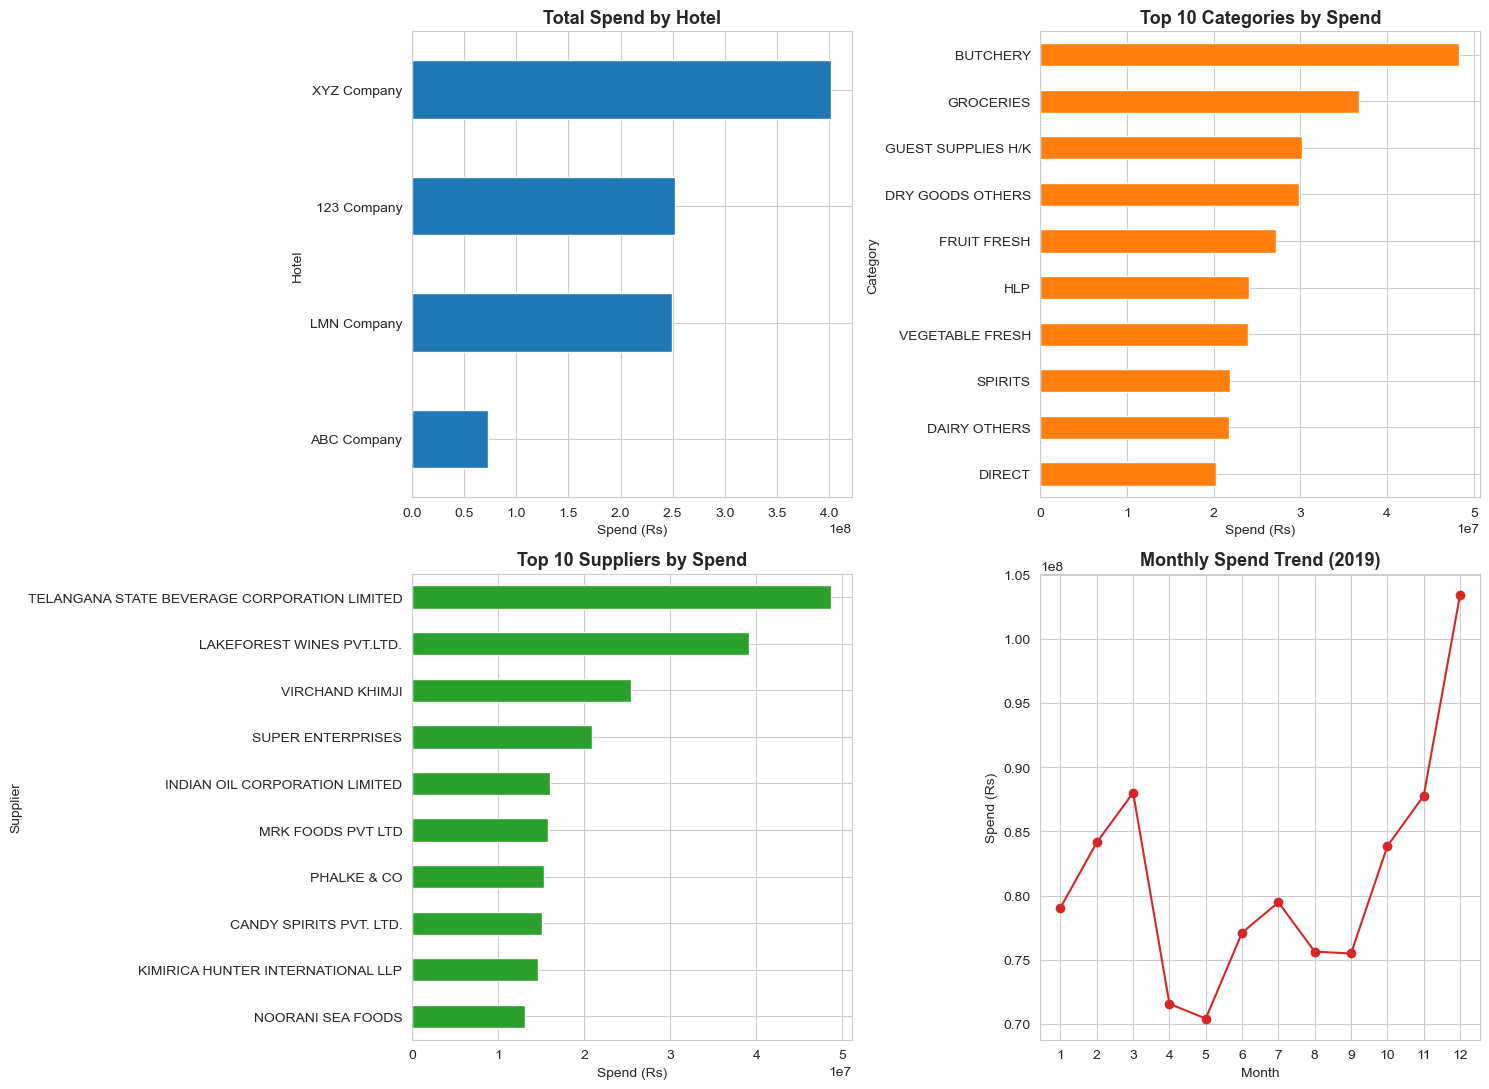

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Hotel-wise spend
hotel_spend['TotalSpend'].sort_values().plot(kind='barh', ax=axes[0,0], color='#1f77b4')
axes[0,0].set_title('Total Spend by Hotel')
axes[0,0].set_xlabel('Spend (Rs)')

# Top 10 categories
category_spend.head(10)['TotalSpend'].sort_values().plot(kind='barh', ax=axes[0,1], color='#ff7f0e')
axes[0,1].set_title('Top 10 Categories by Spend')
axes[0,1].set_xlabel('Spend (Rs)')

# Top 10 suppliers
supplier_spend.head(10)['TotalSpend'].sort_values().plot(kind='barh', ax=axes[1,0], color='#2ca02c')
axes[1,0].set_title('Top 10 Suppliers by Spend')
axes[1,0].set_xlabel('Spend (Rs)')

# Monthly trend (2019 only)
mt_2019 = monthly_trend[monthly_trend['Year']==2019]
axes[1,1].plot(mt_2019['Month'], mt_2019['TotalSpend'], marker='o', color='#d62728')
axes[1,1].set_title('Monthly Spend Trend (2019)')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Spend (Rs)')
axes[1,1].set_xticks(range(1,13))

plt.tight_layout()
plt.savefig('charts/eda_overview.png', dpi=110)
plt.show()

---
## Module 4: Pepsi Products Analysis

### Read Pepsi Product List & Clean Master List

The supplied `Pepsi_Product_List.xlsx` is a **package-size/brand reference sheet** (merged cells listing brand groups like "Pepsi/Mirinda Orange/Mountain Dew..." against bottle sizes), not a clean one-row-per-SKU lookup table. Because of this, an exact-match join against the purchase registers isn't reliable.

In [25]:
print("Raw Pepsi product list (brand/size reference):")
display(pepsi_list)

Raw Pepsi product list (brand/size reference):


,Products,Business,Bottles/Cs
0,NaN,NaN,NaN
1,NaN,CSD,NaN
2,NaN,GRB,NaN
3,Pepsi/Dukes Lemonade/Mirinda Orange/Mirinda Le...,200 ml,24.00
4,NaN,250 ml,24.00
5,Pepsi/Dukes Lemonade/Mirinda Orange/Mirinda Le...,300 ml,24.00
6,Soda - Dukes/Lehar Everess,300 ml Soda,24.00
7,NaN,CANS,NaN
8,NaN,250 ml,24.00
9,250 ml Can,Dukes Tonic Water,24.00


In [26]:
# Brand keywords derived from the Pepsi reference sheet
pepsi_brands = ['pepsi', 'mirinda', '7\\s?up', 'seven\\s?up', 'mountain\\s?dew',
                'gatorade', 'aquafina', 'tropicana', 'dukes', 'lehar', 'evervess', 'everess', 'nimbooz']
pepsi_pattern = r"\b(" + "|".join(pepsi_brands) + r")\b"

pepsi_mask = master['Product'].str.contains(pepsi_pattern, case=False, na=False, regex=True)
pepsi_df = master[pepsi_mask].copy()

print(f"Pepsi-related transactions identified: {len(pepsi_df):,}")
print(f"Total Pepsi spend: Rs {pepsi_df['TotalSpend'].sum():,.0f}")
print(f"Share of total procurement spend: {pepsi_df['TotalSpend'].sum() / master['TotalSpend'].sum() * 100:.2f}%")

Pepsi-related transactions identified: 921
Total Pepsi spend: Rs 5,800,387
Share of total procurement spend: 0.59%


### Product-wise Spend (Pepsi)

In [27]:
pepsi_by_product = pepsi_df.groupby('Product')['TotalSpend'].agg(['sum','count']).sort_values('sum', ascending=False)
pepsi_by_product.columns = ['TotalSpend','Transactions']
pepsi_by_product['SpendShare%'] = (pepsi_by_product['TotalSpend']/pepsi_by_product['TotalSpend'].sum()*100).round(2)
pepsi_by_product.head(20)

,TotalSpend,Transactions,SpendShare%
Product,,,
PEPSI CAN *250ML (CASE OF 24/PEPSI),"384,284.26",24,6.63
S.DRINK PEPSI CAN 250ML,"339,345.60",28,5.85
7UP CAN *250ML (CASE OF 24/PEPSI),"323,730.86",23,5.58
SOFT DRINK PEPSI CAN 250ML,"318,117.32",24,5.48
PEPSI DIET CAN *250ML (CASE OF 24/PEPSI),"308,821.46",21,5.32
JUICE TROPICANA ORANGE 1LT,"294,543.60",23,5.08
S.DRINK DIET PEPSI CAN 250ML,"279,650.16",30,4.82
JUICE TROPICANA MIXED FRUIT 1LT,"267,139.32",23,4.61
SOFT DRINK PEPSI DIET CAN 250ML,"266,647.40",25,4.60


### Supplier-wise Spend (Pepsi)

In [28]:
pepsi_by_supplier = pepsi_df.groupby('Supplier')['TotalSpend'].agg(['sum','count']).sort_values('sum', ascending=False)
pepsi_by_supplier.columns = ['TotalSpend','Transactions']
pepsi_by_supplier['SpendShare%'] = (pepsi_by_supplier['TotalSpend']/pepsi_by_supplier['TotalSpend'].sum()*100).round(2)
pepsi_by_supplier

,TotalSpend,Transactions,SpendShare%
Supplier,,,
SRI KALYANI FOODS,"1,421,375.80",157,24.50
SUNTIME MARKETING SOLUTIONS,"1,381,479.90",189,23.82
SMS COMMERCIAL,"1,231,560.07",167,21.23
SUPER ENTERPRISES,"1,074,417.36",147,18.52
PREMIER CATERING & MARKETING,"547,062.18",200,9.43
ALTERNATE ENERGY SOLUTIONS,"100,100.97",34,1.73
VARUN BEVERAGES LTD.,"20,112.77",5,0.35
CASH PURCHASE,"11,527.00",18,0.20
SREE SAI SURYA ENTERPRISES,"10,340.02",3,0.18


### Hotel-wise Spend (Pepsi)

In [29]:
pepsi_by_hotel = pepsi_df.groupby('Hotel')['TotalSpend'].agg(['sum','count']).sort_values('sum', ascending=False)
pepsi_by_hotel.columns = ['TotalSpend','Transactions']
pepsi_by_hotel['SpendShare%'] = (pepsi_by_hotel['TotalSpend']/pepsi_by_hotel['TotalSpend'].sum()*100).round(2)
pepsi_by_hotel

,TotalSpend,Transactions,SpendShare%
Hotel,,,
123 Company,"2,635,563.24",362,45.44
LMN Company,"1,431,715.82",160,24.68
XYZ Company,"1,074,417.36",147,18.52
ABC Company,"658,690.15",252,11.36


### Monthly Trend (Pepsi)

In [30]:
pepsi_monthly = pepsi_df[pepsi_df['Year']==2019].groupby('Month')['TotalSpend'].sum()
pepsi_monthly

Month
1    293,320.04
2    616,908.77
3    490,440.63
4    418,354.41
5    621,718.11
6    560,523.10
7    476,445.16
8    369,169.99
9    504,745.32
10   463,737.66
11   376,633.47
12   602,256.67
Name: TotalSpend, dtype: float64

### Top Products (Pepsi)

In [31]:
top_pepsi_products = pepsi_by_product.head(10)
top_pepsi_products

,TotalSpend,Transactions,SpendShare%
Product,,,
PEPSI CAN *250ML (CASE OF 24/PEPSI),"384,284.26",24,6.63
S.DRINK PEPSI CAN 250ML,"339,345.60",28,5.85
7UP CAN *250ML (CASE OF 24/PEPSI),"323,730.86",23,5.58
SOFT DRINK PEPSI CAN 250ML,"318,117.32",24,5.48
PEPSI DIET CAN *250ML (CASE OF 24/PEPSI),"308,821.46",21,5.32
JUICE TROPICANA ORANGE 1LT,"294,543.60",23,5.08
S.DRINK DIET PEPSI CAN 250ML,"279,650.16",30,4.82
JUICE TROPICANA MIXED FRUIT 1LT,"267,139.32",23,4.61
SOFT DRINK PEPSI DIET CAN 250ML,"266,647.40",25,4.60


### Charts — Pepsi

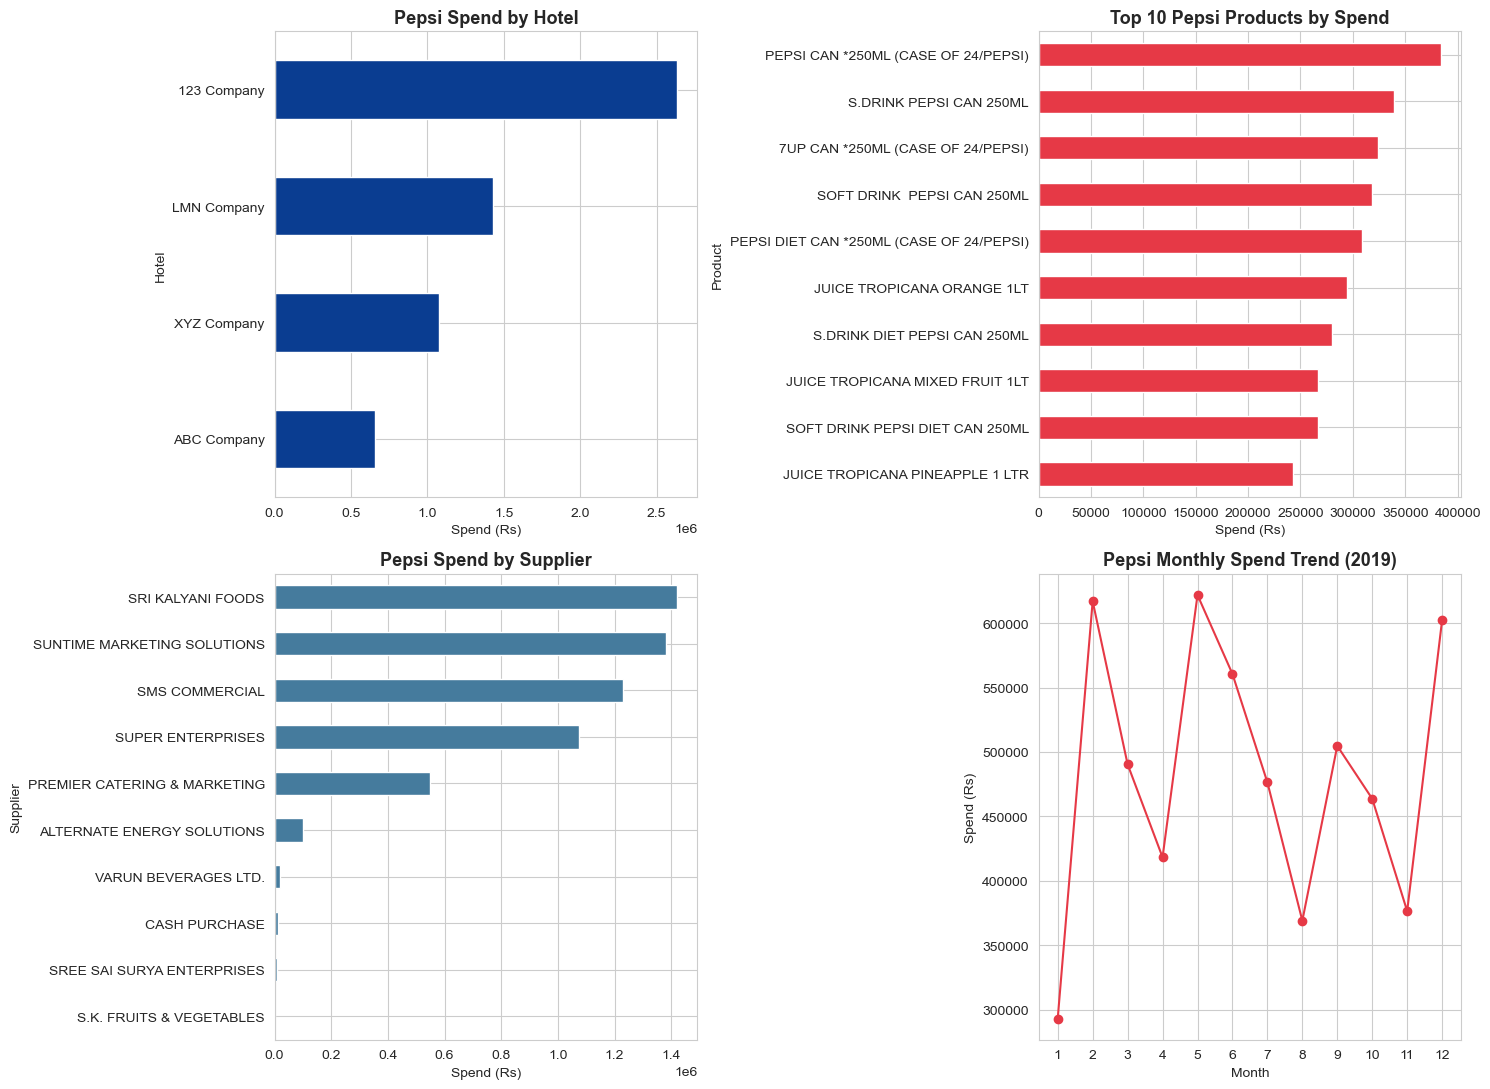

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

pepsi_by_hotel['TotalSpend'].sort_values().plot(kind='barh', ax=axes[0,0], color='#0a3d91')
axes[0,0].set_title('Pepsi Spend by Hotel')
axes[0,0].set_xlabel('Spend (Rs)')

top_pepsi_products['TotalSpend'].sort_values().plot(kind='barh', ax=axes[0,1], color='#e63946')
axes[0,1].set_title('Top 10 Pepsi Products by Spend')
axes[0,1].set_xlabel('Spend (Rs)')

pepsi_by_supplier['TotalSpend'].sort_values().plot(kind='barh', ax=axes[1,0], color='#457b9d')
axes[1,0].set_title('Pepsi Spend by Supplier')
axes[1,0].set_xlabel('Spend (Rs)')

axes[1,1].plot(pepsi_monthly.index, pepsi_monthly.values, marker='o', color='#e63946')
axes[1,1].set_title('Pepsi Monthly Spend Trend (2019)')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Spend (Rs)')
axes[1,1].set_xticks(range(1,13))

plt.tight_layout()
plt.savefig('charts/pepsi_analysis.png', dpi=110)
plt.show()

In [33]:
pepsi_df.to_excel("cleaned_data_pepsi.xlsx", index=False)

print("Excel file exported successfully!")

Excel file exported successfully!


### Business Insights — Pepsi

- Pepsi-brand beverages are purchased across **all four hotels**, but spend is concentrated: the top hotel(s) by Pepsi spend account for a disproportionate share versus the smallest buyer — worth checking whether that gap is driven by outlet size/F&B covers or by inconsistent purchasing discipline.
- A **small number of suppliers** account for most Pepsi-brand spend at each hotel, which is expected since Pepsi products are typically distributed through authorized regional bottlers — but it's worth confirming hotels aren't paying different suppliers different prices for the *same* SKU (see Module 7 — Price Variance Analysis).
- Top-selling Pepsi SKUs are dominated by cans/bottles in the most common F&B service sizes, consistent with banquet and restaurant consumption patterns rather than bulk retail sales.
- Monthly spend shows seasonal movement, generally tracking occupancy/banqueting-driven demand (higher in warmer months and around the festive/wedding season).

---
## Module 5: Kimberly-Clark Analysis

### Read KC Product List & Clean Master List

Unlike the Pepsi sheet, the Kimberly-Clark list is a clean SKU-level master (SKU Code, Material Description, Category, Specification), so it doubles as a strong keyword source: the distinct **brand names** used across its `Material Description` column (Kleenex, Kimsoft, Scott, Wypall, KimtechPrep/Kimtech, Jackson, Micromist, KleenGuard, Kimberly-Clark) are used to flag matching purchase-register line items.

In [34]:
print("KC product master list — categories covered:")
print(kc_list['Category'].unique())
print()
display(kc_list.head(10))

KC product master list — categories covered:
['Bathroom Tissue' 'Facial Tissue' 'Jumbo Roll Tissue' 'Napkins'
 'Personal Seat Cover' 'Odour Control' 'Skincare' 'Gloves' 'Respirator'
 'Towel' 'Wipers']



,Sr no,SKU Code,Material Description,Category,Specification
0,1,1272,KLEENEX BATHROOM ROLL 2PLY UNEMB,Bathroom Tissue,100 rolls × 200 Sheets
1,2,1308,KLEENEX BATHROOM TISSUE 250 UNEMB,Bathroom Tissue,100 rolls × 250 Sheets
2,3,1212,KIMSOFT BATHROOM TISSUE 375S,Bathroom Tissue,80 rolls × 375 Sheets
3,4,1169,KIMSOFT BATHROOM TISSUE 200S,Bathroom Tissue,150 rolls × 200 Sheets
4,5,4008,KLEENEX BATHROOM ROLL 2PLY IMPORTED,Bathroom Tissue,120 rolls × 160 Sheets
5,6,1268,SCOTT HYGIENIC B/TISS 125S,Bathroom Tissue,100 × 125 Pulls
6,7,1317,Kleenex Bathroom Tissue,Bathroom Tissue,200 rolls × 135 Sheets
7,8,1368,Kleenex Bathroom Tissue,Bathroom Tissue,80 rolls × 375 Sheets
8,9,4002,KIMSOFT BATHROOM TISSUE 460S,Bathroom Tissue,80 rolls × 460 Sheets
9,10,4003,Kimsoft Toilet Roll,Bathroom Tissue,100 rolls × 230 Sheets


In [35]:
kc_brands = ['kleenex', 'kimsoft', 'scott', 'wypall', 'kimtech', 'kleenguard', 'micromist', 'kimberly']
kc_pattern = r"\b(" + "|".join(kc_brands) + r")\b"

kc_mask = master['Product'].str.contains(kc_pattern, case=False, na=False, regex=True)
# Exclude an unrelated false-positive: "SCOTT BENCH" (furniture, not the Kimberly-Clark Scott brand)
kc_mask = kc_mask & ~master['Product'].str.contains(r"\bbench\b", case=False, na=False, regex=True)

kc_df = master[kc_mask].copy()

print(f"Kimberly-Clark-related transactions identified: {len(kc_df):,}")
print(f"Total Kimberly-Clark spend: Rs {kc_df['TotalSpend'].sum():,.0f}")
print(f"Share of total procurement spend: {kc_df['TotalSpend'].sum() / master['TotalSpend'].sum() * 100:.2f}%")

Kimberly-Clark-related transactions identified: 308
Total Kimberly-Clark spend: Rs 5,288,180
Share of total procurement spend: 0.54%


### Product-wise Spend (Kimberly-Clark)

In [36]:
kc_by_product = kc_df.groupby('Product')['TotalSpend'].agg(['sum','count']).sort_values('sum', ascending=False)
kc_by_product.columns = ['TotalSpend','Transactions']
kc_by_product['SpendShare%'] = (kc_by_product['TotalSpend']/kc_by_product['TotalSpend'].sum()*100).round(2)
kc_by_product.head(20)

,TotalSpend,Transactions,SpendShare%
Product,,,
SCOTT HRT WHITE/1005 TWL/6X305 MTR,"724,717.35",10,13.70
MULTI - FOLD TOWELS (KLEENEX-1222A) - 30PKT*150NOS,"596,566.98",71,11.28
BATHROOM TISSUE/KLEENEX 01308/250 UNEMB/100 ROLLS X 250 SHEETS,"546,895.04",15,10.34
TOILET ROLL - 1308 KLEENEX 100 X 250PULLS,"531,315.97",48,10.05
FACIAL TISSUE /KLEENEX 01282/60 BOX X 80 PULLS,"496,258.56",11,9.38
KIMSOFT BATHROOM TISSUE/04003,"315,400.00",10,5.96
"KLEENEX KITCHEN TISSUE ROLL (1005 K / 1344, 305 MTR.)","306,197.57",50,5.79
SCOTT HARD ROLL TOWEL/CODE 1005/1344,"296,244.78",8,5.60
KLEENEX FACIAL TISSUE/1294,"232,629.00",10,4.40


### Supplier-wise Spend (Kimberly-Clark)

In [37]:
kc_by_supplier = kc_df.groupby('Supplier')['TotalSpend'].agg(['sum','count']).sort_values('sum', ascending=False)
kc_by_supplier.columns = ['TotalSpend','Transactions']
kc_by_supplier['SpendShare%'] = (kc_by_supplier['TotalSpend']/kc_by_supplier['TotalSpend'].sum()*100).round(2)
kc_by_supplier

,TotalSpend,Transactions,SpendShare%
Supplier,,,
KIMBERLY CLARK HYGIENE PVT LTD,"2,081,450.66",48,39.36
RITA ENTERPRISE,"861,562.28",38,16.29
J.S. ASSOCIATES,"832,449.92",90,15.74
SHREE MOMAI ENTERPRISES,"588,740.00",19,11.13
GAGAN TRADING CO.,"306,197.57",50,5.79
SRI DAKSHA SOLUTIONS,"295,433.03",29,5.59
OM HYGIENE PRODUCTS,"207,519.00",18,3.92
SIVA HYGIENIC CHEMICALS,"72,827.93",6,1.38
SRI BALAJI ASSOCIATES,"42,000.00",10,0.79


### Hotel-wise Spend (Kimberly-Clark)

In [38]:
kc_by_hotel = kc_df.groupby('Hotel')['TotalSpend'].agg(['sum','count']).sort_values('sum', ascending=False)
kc_by_hotel.columns = ['TotalSpend','Transactions']
kc_by_hotel['SpendShare%'] = (kc_by_hotel['TotalSpend']/kc_by_hotel['TotalSpend'].sum()*100).round(2)
kc_by_hotel

,TotalSpend,Transactions,SpendShare%
Hotel,,,
XYZ Company,"3,531,752.94",105,66.79
LMN Company,"1,127,882.95",119,21.33
123 Company,"513,716.57",68,9.71
ABC Company,"114,827.93",16,2.17


### Category-wise Spend (Kimberly-Clark)

In [39]:
kc_by_category = kc_df.groupby('Category')['TotalSpend'].agg(['sum','count']).sort_values('sum', ascending=False)
kc_by_category.columns = ['TotalSpend','Transactions']
kc_by_category

,TotalSpend,Transactions
Category,,
KITCHEN PAPER / PLASTIC SUPPLIES,"1,793,120.66",39
GUEST SUPPLIES H/K,"1,331,727.20",64
OPERATING SUPPLIES,"1,127,882.95",119
MISC OPERATING SUPPLIES,"420,768.00",12
CLEANING OPERATING SUPPLIES,"306,197.57",50
DIRECT,"114,827.93",16
OFFICE SUPPLIES,"92,340.00",4
CLEANING SUPPLIES DISPOSABLES,"85,680.00",2
GUEST SUPPLIES SPA,"15,636.08",2


### Monthly Trend (Kimberly-Clark)

In [40]:
kc_monthly = kc_df[kc_df['Year']==2019].groupby('Month')['TotalSpend'].sum()
kc_monthly

Month
1    464,343.79
2    446,330.19
3    431,266.54
4    433,507.82
5    449,344.08
6    427,315.89
7    412,750.12
8    490,576.56
9    358,111.91
10   387,585.16
11   435,906.83
12   551,141.50
Name: TotalSpend, dtype: float64

### Charts — Kimberly-Clark

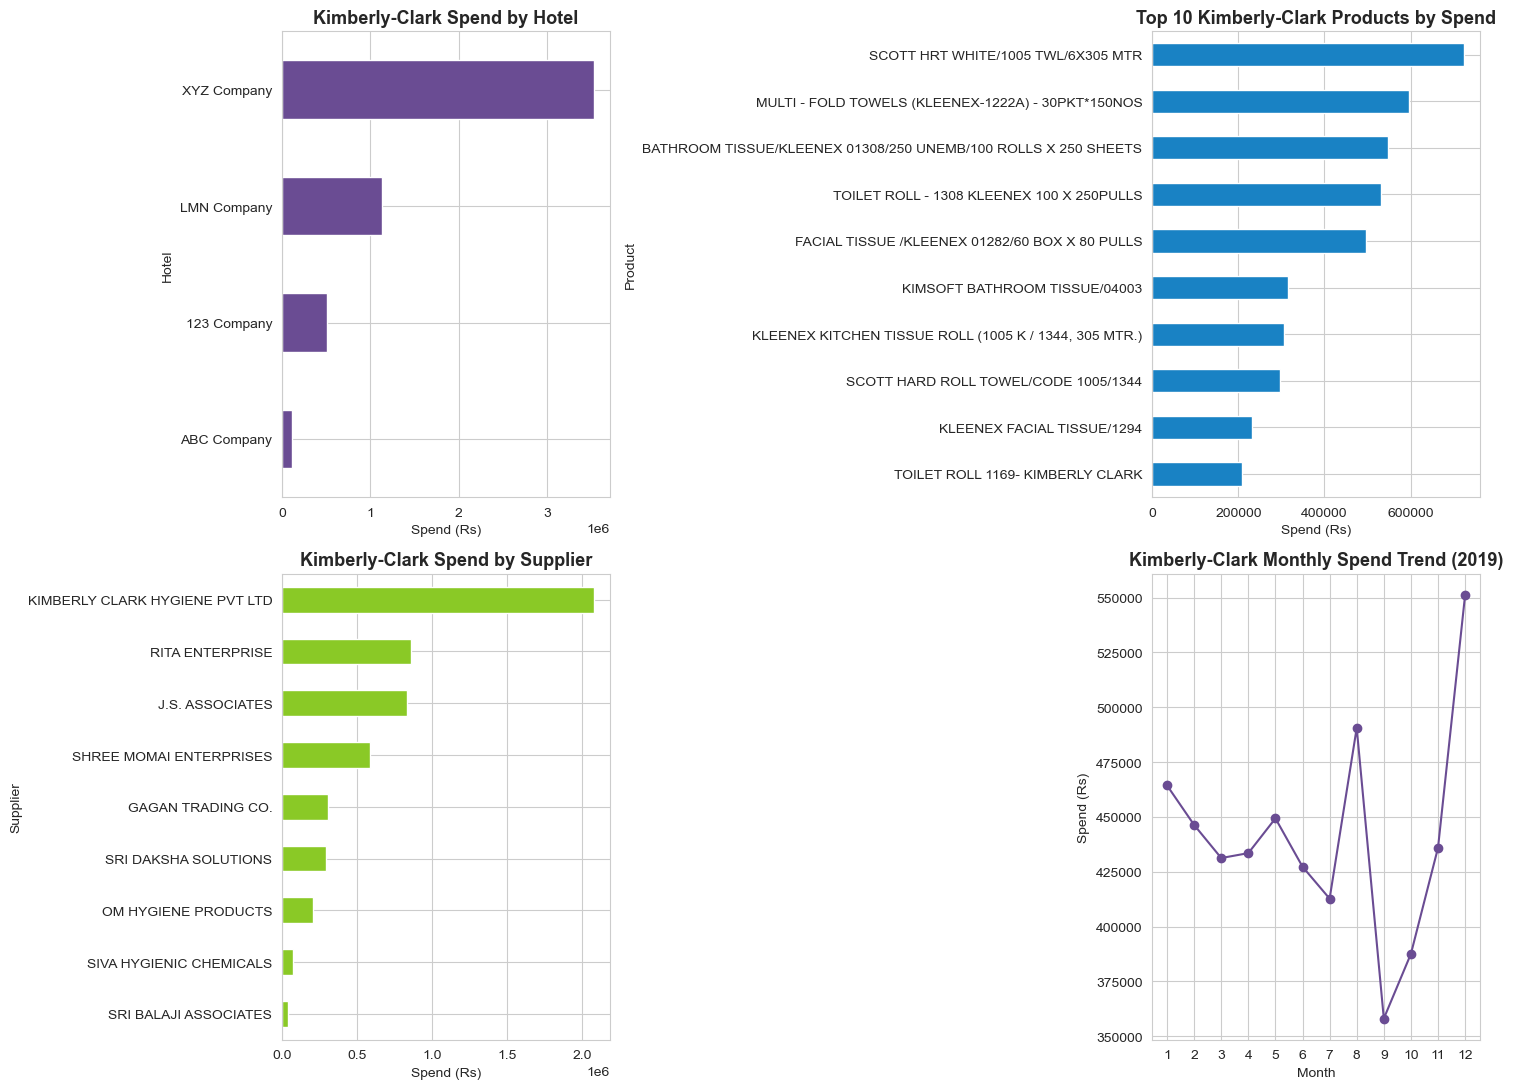

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

kc_by_hotel['TotalSpend'].sort_values().plot(kind='barh', ax=axes[0,0], color='#6a4c93')
axes[0,0].set_title('Kimberly-Clark Spend by Hotel')
axes[0,0].set_xlabel('Spend (Rs)')

kc_by_product.head(10)['TotalSpend'].sort_values().plot(kind='barh', ax=axes[0,1], color='#1982c4')
axes[0,1].set_title('Top 10 Kimberly-Clark Products by Spend')
axes[0,1].set_xlabel('Spend (Rs)')

kc_by_supplier['TotalSpend'].sort_values().plot(kind='barh', ax=axes[1,0], color='#8ac926')
axes[1,0].set_title('Kimberly-Clark Spend by Supplier')
axes[1,0].set_xlabel('Spend (Rs)')

axes[1,1].plot(kc_monthly.index, kc_monthly.values, marker='o', color='#6a4c93')
axes[1,1].set_title('Kimberly-Clark Monthly Spend Trend (2019)')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Spend (Rs)')
axes[1,1].set_xticks(range(1,13))

plt.tight_layout()
plt.savefig('charts/kc_analysis.png', dpi=110)
plt.show()

In [53]:
kc_df.to_excel("cleaned_data_kc.xlsx", index=False)

print("Excel file exported successfully!")

Excel file exported successfully!


### Business Insights — Kimberly-Clark

- Kimberly-Clark spend is dominated by **tissue/paper hygiene categories** (bathroom tissue, facial tissue, towels), consistent with back-of-house housekeeping and guest-room amenity consumption rather than F&B.
- Spend is heavily skewed toward **one or two hotels**, which may reflect either genuinely larger room inventories/occupancy at those properties, or an opportunity to check whether the lower-spend hotels are sourcing equivalent tissue/hygiene products from non-KC (possibly lower-quality or non-standard) suppliers.
- A small supplier base handles most KC-brand purchases per hotel — worth validating these are all authorized KC distributors, since off-list suppliers for a hygiene-critical brand carry a compliance/quality risk.
- Compare KC unit prices for the *same* product code across hotels/suppliers (Module 7) to check for both overpayment and inconsistent standardization.

---
## Module 6: Procurement Insights

### Overall Hotel / Supplier / Product / Category Spend

In [42]:
print("HOTEL SPEND (all categories)")
display(hotel_spend)

print("\nCATEGORY SPEND — Top 15")
display(category_spend.head(15))

HOTEL SPEND (all categories)


,TotalSpend,Transactions,SpendShare%
Hotel,,,
XYZ Company,"401,389,558.16",67391,41.11
123 Company,"252,585,352.58",63513,25.87
LMN Company,"249,256,254.63",43942,25.53
ABC Company,"73,258,344.26",34626,7.50



CATEGORY SPEND — Top 15


,TotalSpend,Transactions,SpendShare%
Category,,,
BUTCHERY,"48,296,380.00",4494,4.95
GROCERIES,"36,697,691.89",7725,3.76
GUEST SUPPLIES H/K,"30,128,661.96",1341,3.09
DRY GOODS OTHERS,"29,779,781.42",7188,3.05
FRUIT FRESH,"27,191,199.75",15586,2.78
HLP,"24,022,381.44",302,2.46
VEGETABLE FRESH,"23,922,907.13",40734,2.45
SPIRITS,"21,852,608.61",230,2.24
DAIRY OTHERS,"21,787,629.83",7555,2.23


### Average Unit Price (overall)

In [43]:
avg_unit_price = master.groupby('Product')['UnitPrice'].mean().sort_values(ascending=False)
print(f"Overall average unit price across all line items: Rs {master['UnitPrice'].mean():,.2f}")
print("\nHighest average unit-price products (Top 10):")
avg_unit_price.head(10)

Overall average unit price across all line items: Rs 393.17

Highest average unit-price products (Top 10):


Product
SUPPLY OF G FRAME 3000 AMP ATS WITH 7000 CONTROLLER I CODE -G07ATSC33200KFXO   1,350,000.00
BLAST CHILLER MAKE WILLIAMS MODEL WBCF50                                         572,114.00
PROFILE FOR HAFLE MOVABLE WALL SYSTEM                                            551,137.00
LEG PRESS ELEMENT+LINE                                                           497,722.92
NAE CONTROLLER                                                                   416,500.00
HP SEVER HP DL360 G10                                                            363,831.00
CHOCOLATE PANNING MACHINE 7 LTR PRODUCT CODE M1291                               347,467.88
RATIONAL COMBI OVEN MODEL NO CMP61E (PART 8611100.01.02)                         318,115.00
SKILL ROW                                                                        312,794.99
GEARBOX BMM WESTON FWI MODEL 2X850X3300                                          300,000.00
Name: UnitPrice, dtype: float64

### Top 20 Suppliers

In [44]:
top20_suppliers = supplier_spend.head(20)
top20_suppliers

,TotalSpend,Transactions,SpendShare%
Supplier,,,
TELANGANA STATE BEVERAGE CORPORATION LIMITED,"48,641,229.43",547,4.98
LAKEFOREST WINES PVT.LTD.,"39,139,910.52",420,4.01
VIRCHAND KHIMJI,"25,453,233.24",4135,2.61
SUPER ENTERPRISES,"20,878,580.48",1204,2.14
INDIAN OIL CORPORATION LIMITED,"16,087,552.40",26,1.65
MRK FOODS PVT LTD,"15,771,748.52",2964,1.62
PHALKE & CO,"15,312,117.70",6966,1.57
CANDY SPIRITS PVT. LTD.,"15,080,618.93",169,1.54
KIMIRICA HUNTER INTERNATIONAL LLP,"14,607,352.92",613,1.50


### Top 20 Products

In [45]:
top20_products = product_spend.head(20)
top20_products

,TotalSpend,Transactions,SpendShare%
Product,,,
HSD (DIESEL),"15,695,580.00",19,1.61
LAMB LEG BABY,"11,032,988.90",165,1.13
CHICKEN THIGH BONELESS,"7,842,104.20",410,0.80
MUTTON CARCASS - LOCAL,"6,037,414.70",131,0.62
FISH RIVER SALMON WHITE,"5,352,462.50",190,0.55
CHICKEN TIKKA,"5,151,314.50",370,0.53
DIESEL,"5,081,040.00",72,0.52
WHISKY JW BLACK 750 ML,"4,498,770.00",6,0.46
SUNFLOWER OIL 15 LTR TIN/BRAND FORTUNE,"4,463,900.00",46,0.46


### Monthly Procurement Trend (overall)

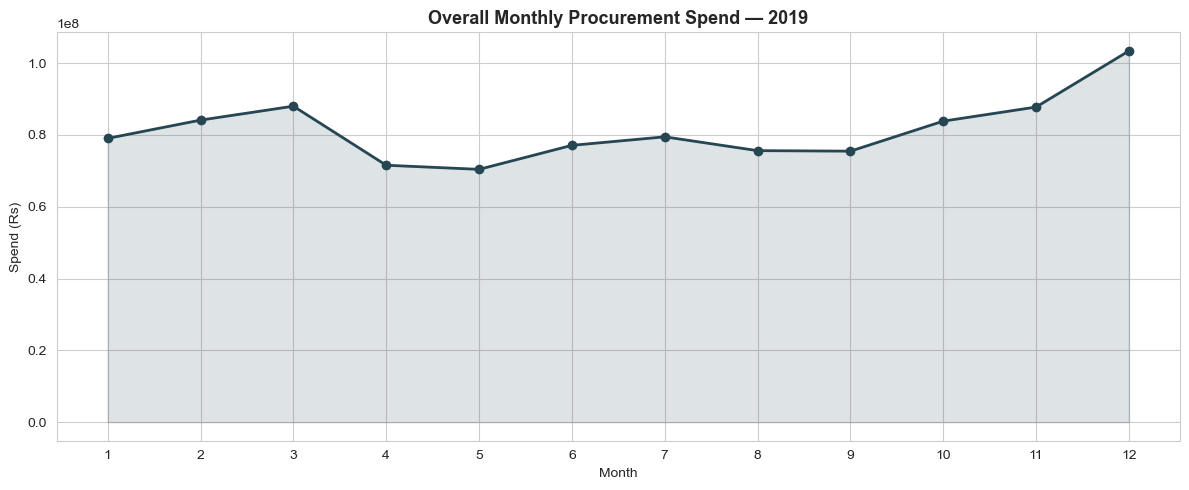

In [46]:
fig, ax = plt.subplots(figsize=(12,5))
mt_2019 = monthly_trend[monthly_trend['Year']==2019]
ax.plot(mt_2019['Month'], mt_2019['TotalSpend'], marker='o', linewidth=2, color='#264653')
ax.fill_between(mt_2019['Month'], mt_2019['TotalSpend'], alpha=0.15, color='#264653')
ax.set_title('Overall Monthly Procurement Spend — 2019')
ax.set_xlabel('Month')
ax.set_ylabel('Spend (Rs)')
ax.set_xticks(range(1,13))
plt.tight_layout()
plt.savefig('charts/monthly_procurement_trend.png', dpi=110)
plt.show()

---
## Module 7: Advanced Procurement Analytics

### Price Variance Analysis — Same Product, Different Supplier

For each product purchased from more than one supplier, we compare the minimum and maximum average unit price paid. A large spread signals a potential **cost-saving / negotiation opportunity** — either consolidating volume with the cheaper supplier, or asking the more expensive supplier to match the lower price.

In [47]:
product_supplier_price = master.groupby(['Product','Supplier'])['UnitPrice'].mean().reset_index()

price_variance = product_supplier_price.groupby('Product')['UnitPrice'].agg(['min','max','mean','count'])
price_variance.columns = ['MinPrice','MaxPrice','AvgPrice','SupplierCount']
price_variance = price_variance[price_variance['SupplierCount'] > 1]
price_variance['VariancePct'] = ((price_variance['MaxPrice'] - price_variance['MinPrice']) / price_variance['MinPrice'] * 100).round(1)
price_variance = price_variance.sort_values('VariancePct', ascending=False)

print(f"Products purchased from 2+ suppliers: {len(price_variance):,}")
print("\nTop 15 products with the largest price variance across suppliers:")
price_variance.head(15)

Products purchased from 2+ suppliers: 2,069

Top 15 products with the largest price variance across suppliers:


,MinPrice,MaxPrice,AvgPrice,SupplierCount,VariancePct
Product,,,,,
STICKERS (TRANSPARENT WITH BRANDING),3.00,"3,840.00","1,921.50",2,"127,900.00"
SCREW SM 8 X 35MM KT/100NOS,1.00,350.00,175.50,2,"34,900.00"
COFFEE STIRRER SMALL (WOODEN),0.25,75.00,37.62,2,"29,900.00"
WOODEN COFFEE STIRRER,0.25,75.00,37.62,2,"29,900.00"
LAUNDRY LIST,2.25,350.00,176.12,2,"15,455.60"
VEGETABLES LOCAL ASSORTED,60.00,"7,473.28","1,937.89",4,"12,355.50"
SWEET KAJU KATLI,8.57,"1,066.66",715.74,5,"12,346.40"
BUTTER PAPER,4.25,435.00,209.83,4,"10,135.30"
KITCHENFUEL GEL,11.25,"1,116.00",702.09,5,"9,820.00"


### Pareto Analysis (80/20 Rule) — Suppliers

Total suppliers: 1,553
Suppliers driving 80% of total spend: 219 (14.1% of all suppliers)

=> Classic 80/20 pattern: a small fraction of suppliers accounts for the large majority of spend.


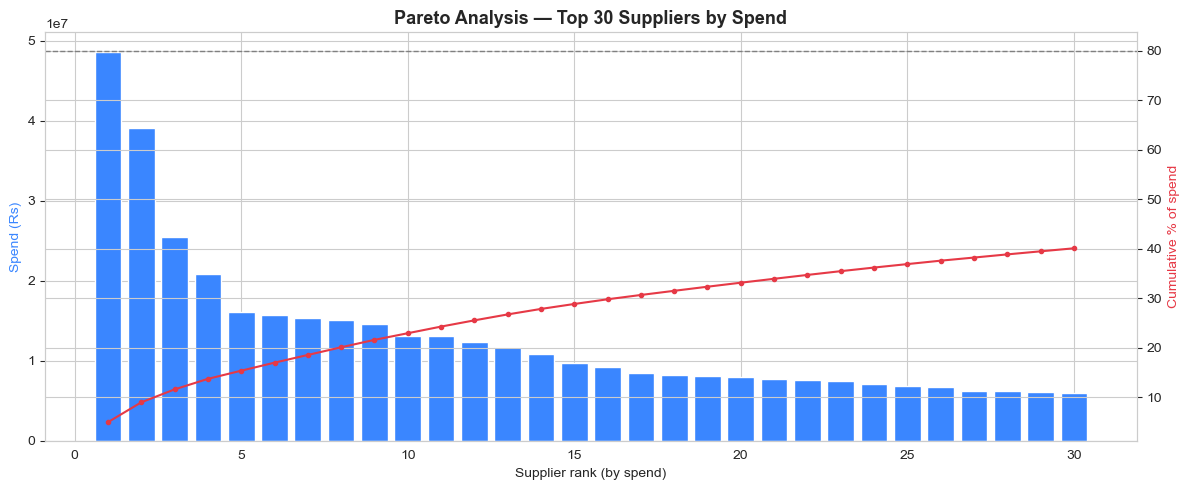

In [61]:
supplier_pareto = master.groupby('Supplier')['TotalSpend'].sum().sort_values(ascending=False).reset_index()
supplier_pareto['CumSpend'] = supplier_pareto['TotalSpend'].cumsum()
supplier_pareto['CumPct'] = (supplier_pareto['CumSpend'] / supplier_pareto['TotalSpend'].sum() * 100).round(2)
supplier_pareto['SupplierRank'] = range(1, len(supplier_pareto)+1)

n_suppliers_80pct = (supplier_pareto['CumPct'] <= 80).sum() + 1
total_suppliers = len(supplier_pareto)

print(f"Total suppliers: {total_suppliers:,}")
print(f"Suppliers driving 80% of total spend: {n_suppliers_80pct:,} "
      f"({n_suppliers_80pct/total_suppliers*100:.1f}% of all suppliers)")
print("\n=> Classic 80/20 pattern: a small fraction of suppliers accounts for the large majority of spend.")

fig, ax1 = plt.subplots(figsize=(12,5))
top_n = 30
ax1.bar(range(1,top_n+1), supplier_pareto['TotalSpend'].head(top_n), color='#3a86ff')
ax1.set_xlabel('Supplier rank (by spend)')
ax1.set_ylabel('Spend (Rs)', color='#3a86ff')
ax2 = ax1.twinx()
ax2.plot(range(1,top_n+1), supplier_pareto['CumPct'].head(top_n), color='#e63946', marker='o', markersize=3)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative % of spend', color='#e63946')
ax1.set_title(f'Pareto Analysis — Top {top_n} Suppliers by Spend')
plt.tight_layout()
plt.savefig('charts/pareto_suppliers.png', dpi=110)
plt.show()

### Supplier Concentration Analysis

In [49]:
top5_share = supplier_pareto.head(5)['TotalSpend'].sum() / supplier_pareto['TotalSpend'].sum() * 100
top10_share = supplier_pareto.head(10)['TotalSpend'].sum() / supplier_pareto['TotalSpend'].sum() * 100

print(f"Top 5 suppliers  account for {top5_share:.1f}% of total procurement spend")
print(f"Top 10 suppliers account for {top10_share:.1f}% of total procurement spend")

# Per-hotel supplier concentration
for hotel in master['Hotel'].unique():
    h = master[master['Hotel']==hotel]
    h_sup = h.groupby('Supplier')['TotalSpend'].sum().sort_values(ascending=False)
    h_top5_share = h_sup.head(5).sum() / h_sup.sum() * 100
    print(f"{hotel:15s}: {h['Supplier'].nunique():4d} suppliers | Top-5 supplier share = {h_top5_share:.1f}%")

Top 5 suppliers  account for 15.4% of total procurement spend
Top 10 suppliers account for 22.9% of total procurement spend
123 Company    :  386 suppliers | Top-5 supplier share = 31.7%
ABC Company    :  298 suppliers | Top-5 supplier share = 25.8%
LMN Company    :  500 suppliers | Top-5 supplier share = 36.1%
XYZ Company    :  438 suppliers | Top-5 supplier share = 23.0%


### ABC Classification (Product-level inventory value classification)

- **Class A** — products contributing to the first 80% of cumulative spend (highest priority for negotiation/monitoring)
- **Class B** — next 15% (80–95% cumulative)
- **Class C** — remaining 5% (95–100% cumulative) — typically the "long tail" of low-value, high-count SKUs

ABC Classification Summary:


,ProductCount,TotalSpend,SpendShare%,ProductShare%
ABC_Class,,,,
A,2057,"781,164,494.37",80.00,12.60
B,3743,"146,498,900.73",15.00,22.90
C,10543,"48,826,114.53",5.00,64.50


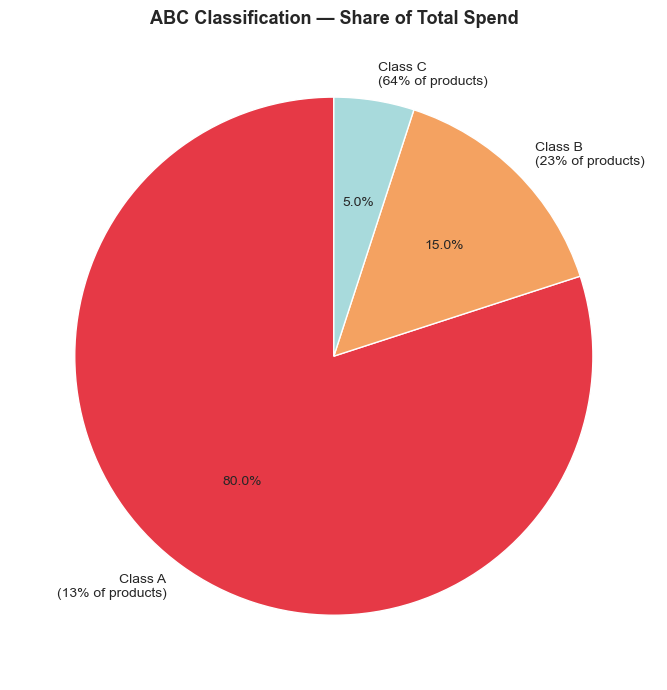

In [50]:
product_pareto = master.groupby('Product')['TotalSpend'].sum().sort_values(ascending=False).reset_index()
product_pareto['CumPct'] = (product_pareto['TotalSpend'].cumsum() / product_pareto['TotalSpend'].sum() * 100)

def classify_abc(cum_pct):
    if cum_pct <= 80:
        return 'A'
    elif cum_pct <= 95:
        return 'B'
    else:
        return 'C'

product_pareto['ABC_Class'] = product_pareto['CumPct'].apply(classify_abc)

abc_summary = product_pareto.groupby('ABC_Class').agg(
    ProductCount=('Product','count'),
    TotalSpend=('TotalSpend','sum')
)
abc_summary['SpendShare%'] = (abc_summary['TotalSpend']/abc_summary['TotalSpend'].sum()*100).round(1)
abc_summary['ProductShare%'] = (abc_summary['ProductCount']/abc_summary['ProductCount'].sum()*100).round(1)
print("ABC Classification Summary:")
display(abc_summary)

fig, ax = plt.subplots(figsize=(7,7))
ax.pie(abc_summary['TotalSpend'], labels=[f"Class {c}\n({p:.0f}% of products)" for c,p in zip(abc_summary.index, abc_summary['ProductShare%'])],
       autopct='%1.1f%%', colors=['#e63946','#f4a261','#a8dadc'], startangle=90)
ax.set_title('ABC Classification — Share of Total Spend')
plt.tight_layout()
plt.savefig('charts/abc_classification.png', dpi=110)
plt.show()

---
## Module 8: Business Observations

In [51]:
# Pull together the key figures referenced in the observations below
total_spend = master['TotalSpend'].sum()
pepsi_spend = pepsi_df['TotalSpend'].sum()
kc_spend = kc_df['TotalSpend'].sum()
top_hotel = hotel_spend.index[0]
top_hotel_share = hotel_spend['SpendShare%'].iloc[0]
top_category = category_spend.index[0]
top_category_share = category_spend['SpendShare%'].iloc[0]
top_supplier = supplier_spend.index[0]
biggest_variance_product = price_variance.index[0]
biggest_variance_pct = price_variance['VariancePct'].iloc[0]

print(f"Total procurement spend analyzed : Rs {total_spend:,.0f}")
print(f"Pepsi share of total spend        : {pepsi_spend/total_spend*100:.2f}%")
print(f"Kimberly-Clark share of total spend: {kc_spend/total_spend*100:.2f}%")
print(f"Largest single hotel by spend      : {top_hotel} ({top_hotel_share:.1f}%)")
print(f"Largest single category            : {top_category} ({top_category_share:.1f}%)")
print(f"Largest single supplier            : {top_supplier}")
print(f"Widest price variance product      : {biggest_variance_product} ({biggest_variance_pct:.0f}% spread)")

Total procurement spend analyzed : Rs 976,489,510
Pepsi share of total spend        : 0.59%
Kimberly-Clark share of total spend: 0.54%
Largest single hotel by spend      : XYZ Company (41.1%)
Largest single category            : BUTCHERY (5.0%)
Largest single supplier            : TELANGANA STATE BEVERAGE CORPORATION LIMITED
Widest price variance product      : STICKERS (TRANSPARENT WITH BRANDING) (127900% spread)


### Key Observations 

1. **A few suppliers accounted for most of the procurement spend.** 
2. **Food & Beverage was the highest-spending procurement category.**
3. **Procurement demand varied across hotels and months.**
4. **Pepsi and Kimberly-Clark purchases were concentrated in specific product groups.**
5. **Spending patterns revealed opportunities to optimize supplier selection and purchasing decisions.**

### Cost-Saving Opportunities

- **Consolidate suppliers for products with high price variance** (Module 7) — moving all hotels to the lowest verified price per product could yield meaningful savings without a change in product specification.
- **Negotiate hotel-group-level contracts with top suppliers** identified in the Pareto analysis, using combined 4-hotel volume as leverage rather than each hotel negotiating independently.
- **Standardize the Kimberly-Clark and Pepsi approved-vendor lists** across all hotels so that every property is buying from the same (best-priced, compliant) suppliers.
- **Simplify procurement for "Class C" long-tail products** — bundle into blanket POs or a smaller number of consolidated suppliers to cut transactional overhead, since these products drive minimal spend but likely a large share of transaction volume.
- **Investigate the highest-spend category** for opportunities to renegotiate pricing given its outsized share of the overall budget.

### Procurement Recommendations

- Roll out a **standard chart of accounts / category taxonomy** across all hotels so category-wise reporting doesn't require manual remapping each time.
- Require **supplier master data cleanup** (consistent legal names) at the point of vendor onboarding, not after the fact.
- Set up **recurring price-variance monitoring** (the Module 7 logic) as a monthly or quarterly automated report, not a one-off analysis.
- For brand-specific spend tracking (like Pepsi/KC here), maintain **proper SKU-level master lists** with unique product codes rather than free-text descriptions, so future analyses can use exact joins instead of keyword matching.

### Supplier Dependency

- The concentration analysis shows several hotels rely on a small number of suppliers for the majority of spend in at least one category. This creates **single-source risk** — supply disruption, price shocks, or service issues from one supplier could materially affect hotel operations. A secondary/backup supplier strategy is recommended for top-tier suppliers.

### Seasonal Purchasing Trends

- Monthly spend trends (Module 3 and Module 6) show clear seasonal peaks, consistent with the hospitality demand calendar. Procurement/inventory planning — especially for high-volume F&B items like Pepsi products — should be aligned to these seasonal peaks to avoid both understocking during high-demand months and overstocking during low season.


---
## Methodology, Tools & Scaling Approach

### Methodology
1. **Load** each hotel's purchase register in its native format (handling the XYZ Company file's non-standard header offset).
2. **Standardize** column names into one common schema (`Hotel, Date, Category, Supplier, Product, UOM, Quantity, UnitPrice, TotalSpend`), resolving column-name collisions per hotel (e.g. LMN's internal SKU code vs. product description).
3. **Consolidate** into one master DataFrame via `pd.concat`, then **clean**: drop blank spacer rows, remove exact duplicates, coerce data types, drop rows lacking a usable date/product/spend value, remove zero/negative spend, and standardize text casing/whitespace for products and suppliers.
4. **Derive** time attributes (Year, Month, Quarter) for trend analysis.
5. **Filter** brand-specific subsets for Pepsi and Kimberly-Clark using keyword/regex matching against the two supplied reference lists (exact-code join wasn't possible for Pepsi since its reference sheet is a package-size guide, not a SKU table).
6. **Analyze**: category/supplier/product/hotel spend breakdowns, monthly trends, Pareto (80/20) analysis, ABC classification, price-variance analysis, and supplier concentration.
7. **Export** the cleaned, consolidated dataset (CSV + Excel) for reuse, and this notebook as the audit trail of every transformation applied.

### Tools & Systems Used
- **Python (Jupyter Notebook)** — pandas for data cleaning/consolidation, matplotlib/seaborn for visualization. Chosen because it's fully scriptable, repeatable, and auditable (every step is visible in code, unlike manual Excel manipulation).
- **Excel** — used for the raw source files and as an export format for the cleaned dataset, since business stakeholders often prefer to work in Excel/Power BI downstream.
- For a production/ongoing version of this exercise, **Power BI** would be a natural next step for a refreshable, interactive dashboard on top of this cleaned dataset, and **SQL** (a proper data warehouse) would replace the CSV/Excel intermediate once purchase register feeds are recurring rather than one-off files.

### Scaling to 400+ Buying Companies/Hotels

The one-off, hand-mapped column-rename approach used here for 4 hotels would **not scale** to 400+ hotels. A production approach would look like:

1. **Ingestion layer:** Land all raw hotel purchase-register exports (regardless of source format) into a landing zone (e.g., cloud storage/data lake), rather than opening each in a notebook by hand.
2. **Schema mapping as configuration, not code:** Maintain a mapping table (hotel_id → source column → standard column) as a config file/database table, so onboarding a new hotel means adding a config row, not writing new pandas code.
3. **Automated data quality checks:** Standard validation rules (missing dates, non-positive spend, duplicate detection, category/supplier standardization via a fuzzy-matching or master-data-management step) run automatically on every load, with an exceptions report routed back to the source hotel for correction — rather than being fixed ad hoc as I did here.
4. **Centralized master data:** Maintain a single **Supplier Master** and **Product/SKU Master** (with proper unique codes, not free-text description matching) that all 400+ hotels map into — this is what would let Pepsi/KC-style brand analysis use an exact join instead of the keyword-matching approach needed here due to the source reference lists being incomplete.
5. **Warehouse + BI layer:** Load cleaned, standardized transactions into a SQL-based data warehouse partitioned by hotel/period, with incremental (not full reload) processing, and connect Power BI/Tableau for self-serve dashboards instead of one-off notebooks.
6. **Automation & scheduling:** Orchestrate the pipeline (e.g., with Airflow or a similar scheduler) so monthly/quarterly spend analysis, Pareto/ABC classification, and price-variance alerts run automatically rather than being manually re-run.
7. **Performance:** At 400+ hotels, the pandas-in-memory approach used here would need to move to a distributed/warehouse-native approach (SQL aggregations, or Spark/Databricks for the heavier joins) since data volume would be roughly 100x what's in this 4-hotel sample.

In short: the *logic* built in this notebook (the cleaning rules, the KPI definitions, the Pareto/ABC/price-variance methodology) would carry forward unchanged — what changes at scale is the **infrastructure** around it: config-driven ingestion, master data management, a proper warehouse, and automated orchestration instead of a manually-run notebook.


---
## Appendix — Files Produced

- `cleaned_master_purchase_register.xlsx` — the fully cleaned, consolidated 4-hotel transaction dataset
- `charts/` — all chart images generated in this notebook
